# Iris Dataset: Simple Exploratory Data Analysis (EDA)

##### Import Modules

In [77]:
import pandas as pd
import numpy as np

# Visualisasi Data
import matplotlib.pyplot as plt 
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_theme(style="whitegrid", palette="deep")

## Iris Dataset: Memahami dataset yang diberikan

##### Load dataset

In [78]:
df = pd.read_csv('../datasets/iris.csv') # membuat file csv ke dataframe
df.head() # menampilkan 5 baris pertama

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


##### Drop column 'id'

In [79]:
# df = df.drop(columns='id')
# df.drop(columns='id', inplace=True) # menghapus kolom bernama 'id'
# df.head() # tampilkan 5 baris pertama

##### Identify the shape of the dataset

In [80]:
df.shape # menampilkan bentuk/dimensi dataset (baris/kolom)

(150, 5)

##### Get the list of columns

In [81]:
df.columns # menampilkan daftar nama kolom

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

##### Identify data types for each column

In [82]:
df.dtypes # menampilkan tipe data tiap kolom

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

##### Get basic dataset information

In [83]:
df.info() # menampilkan informasi dataset

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


##### Identify missing values

In [84]:
# df,isnull().values.any()
df.isna().values.any() # mendeteksi keberadaan nilai kosong

np.False_

##### Indetify duplicate entries/rows

In [85]:
# df[df.duplicated(keep=False)] # Menampilkan seluruh baris dengan duplikasi
df[df.duplicated()] # Menampilkan hanya baris duplikasi sekunder

,sepal_length,sepal_width,petal_length,petal_width,species
34,4.9,3.1,1.5,0.1,setosa
37,4.9,3.1,1.5,0.1,setosa
142,5.8,2.7,5.1,1.9,virginica


#####

##### values count entries/rows

In [86]:
df.duplicated().value_counts() # Menampilkan jumlah duplikasi data

False    147
True       3
Name: count, dtype: int64

##### Cleaning data

In [87]:
# df.dropna(how='all', inplace=True) # Menghapus baris kosong/invalid di akhir data (jika ada)

##### Drop duplicate entries/rows

In [88]:
# df.drop_duplicates(inplace=True) # Menghapus duplikasi data
df.shape # menampilkan bentuk/dimensi dataset (baris/kolom)

(150, 5)

## Iris Dataset: Analisis statistik deskriptif

##### Describe the dataset

In [89]:
df.describe() # menampilkan deskripsi data

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


##### Correlation Matrix

In [90]:
# df.corr()
df.corr(numeric_only=True) # korelasi antar kolom, saya menggunakan numeric_only karna species bertipe object

# sepal_length memiliki korelasi yang baik dengan petal_length yaitu 0.87...
# petal_length memiliki korelasi yang sangat kuat dengan petal_width yaitu 0.96...
# petal_width memiliki korelasi sama kuatnya dengan petal_length yaitu 0.96...

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


## Iris Dataset: Visualisasi data

##### Heatmap
paling cocok untuk memvisualisasikan korelasi matrix

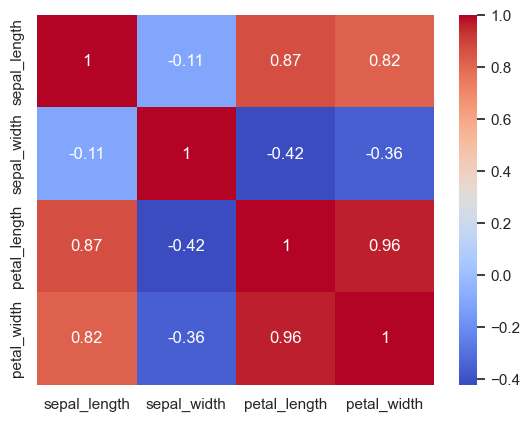

In [91]:
sns.heatmap(data=df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

##### Pair Plot

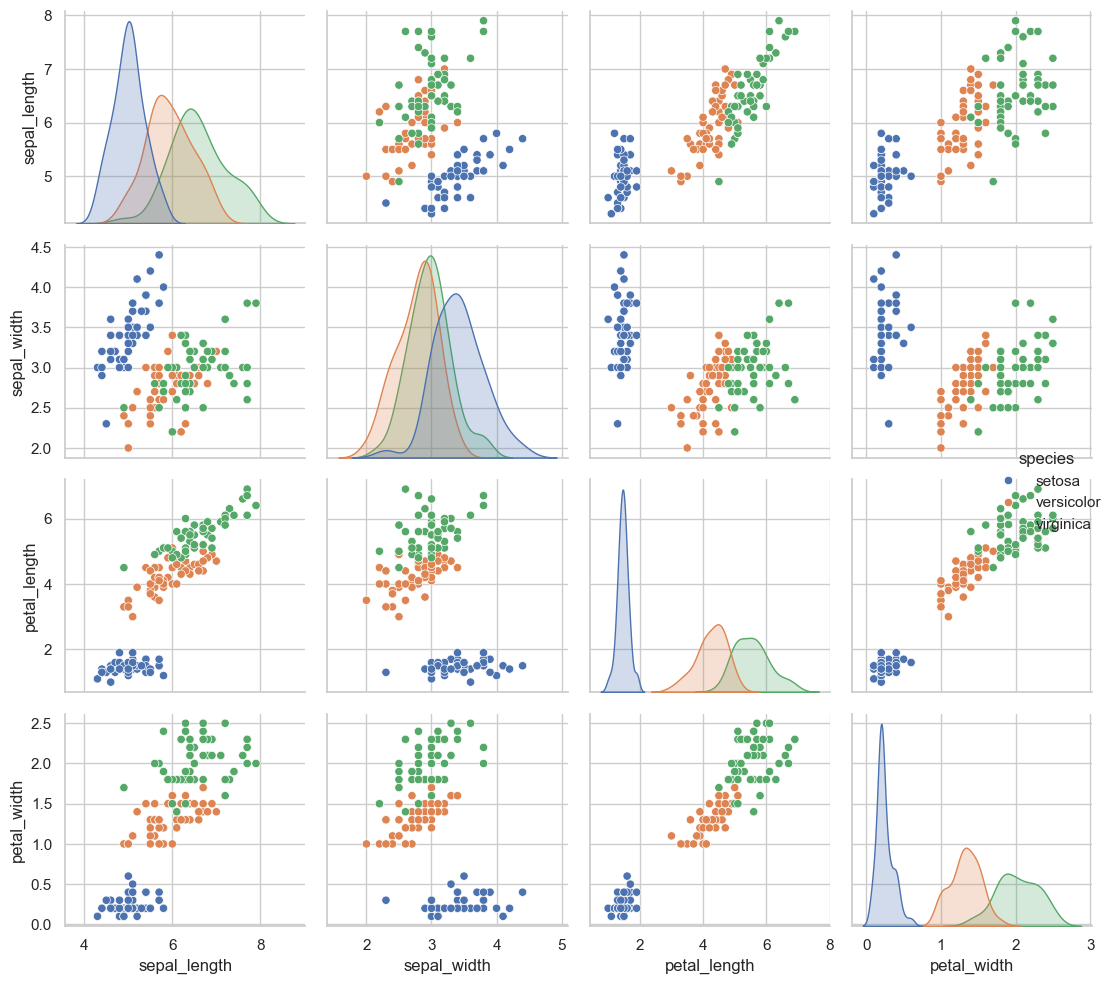

In [92]:
sns.pairplot(data=df, hue='species')
plt.tight_layout()
plt.show()

##### Bar Plot

In [93]:
df['species'].value_counts() # menghitung jumlah setiap species

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

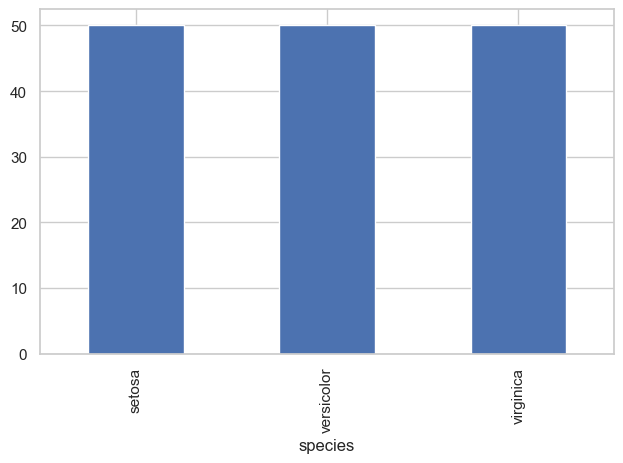

In [94]:
df['species'].value_counts().plot(kind='bar')
plt.tight_layout()
plt.show()

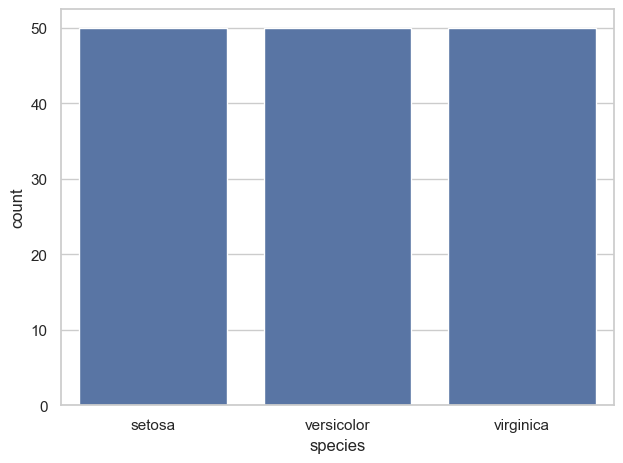

In [95]:
sns.countplot(data=df, x="species")
plt.tight_layout()

##### Pie Chart

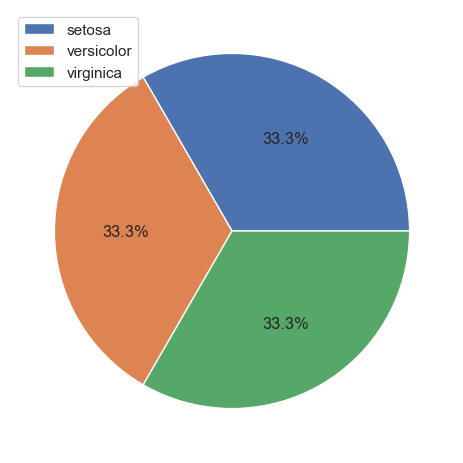

In [96]:
df['species'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=None, legend=True)
plt.tight_layout()
plt.show()

##### Line Plot

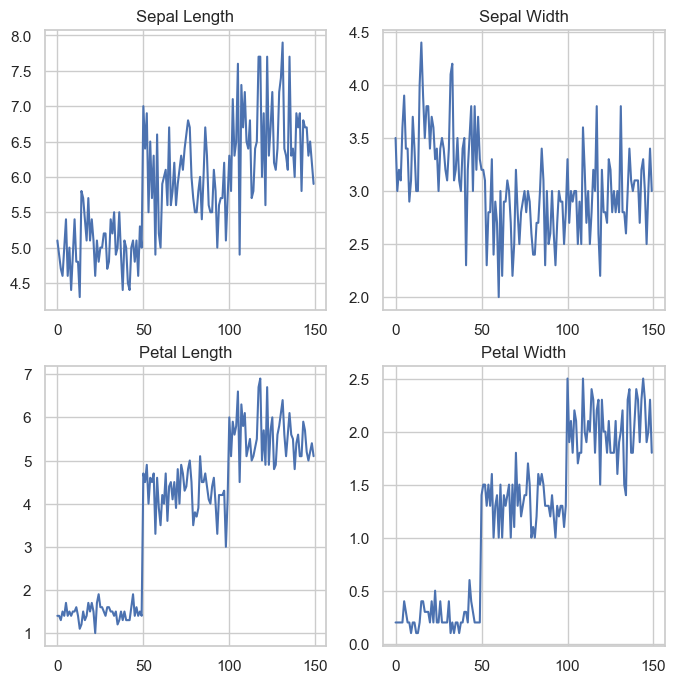

In [97]:
fig,ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

df['sepal_length'].plot.line(ax=ax[0][0])
ax[0][0].set_title('Sepal Length')

df['sepal_width'].plot.line(ax=ax[0][1])
ax[0][1].set_title('Sepal Width')

df['petal_length'].plot.line(ax=ax[1][0])
ax[1][0].set_title('Petal Length')

df['petal_width'].plot.line(ax=ax[1][1])
ax[1][1].set_title('Petal Width')

plt.show()

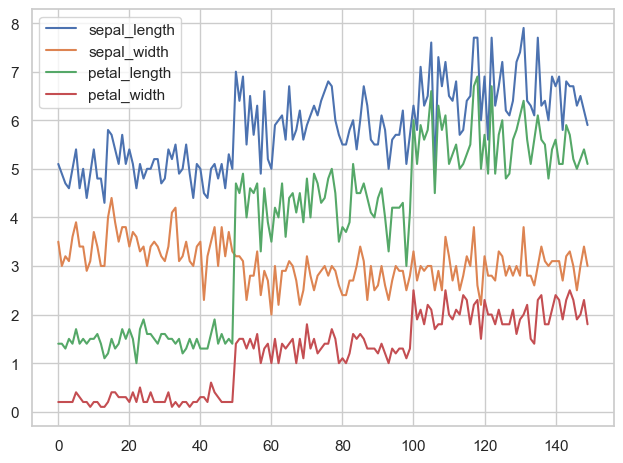

In [98]:
df.plot()
plt.tight_layout()
plt.show()

<Axes: xlabel='petal_length', ylabel='petal_width'>

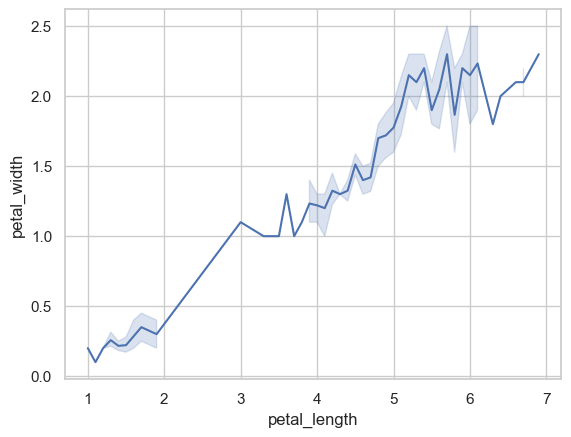

In [99]:
sns.lineplot(data=df, x='petal_length', y='petal_width')

##### Histogram

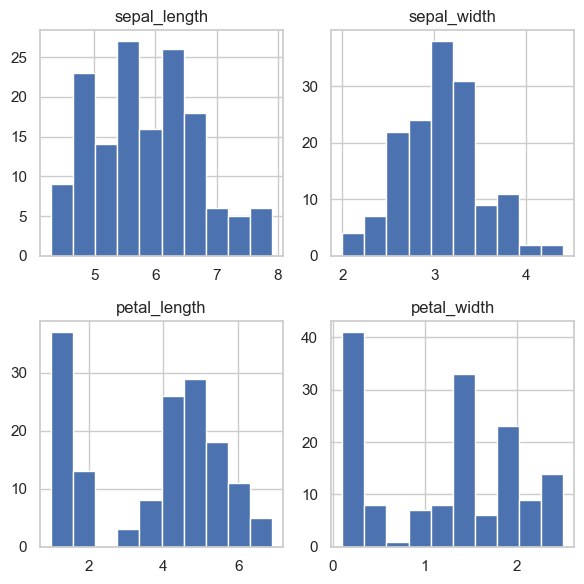

In [100]:
df.hist(figsize=(6,6), bins=10)
plt.tight_layout()
plt.show()

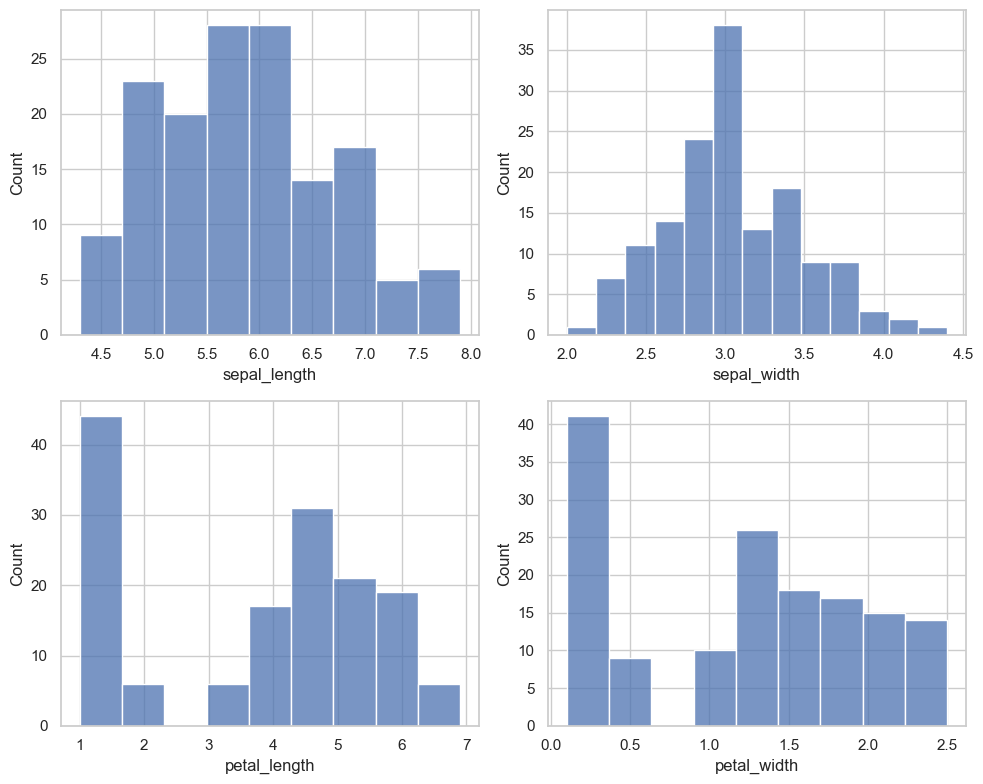

In [101]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8), )

sns.histplot(data=df, x='sepal_length', ax=ax[0][0])
sns.histplot(data=df, x='sepal_width', ax=ax[0][1])
sns.histplot(data=df, x='petal_length', ax=ax[1][0])
sns.histplot(data=df, x='petal_width', ax=ax[1][1])

plt.tight_layout()
plt.show()

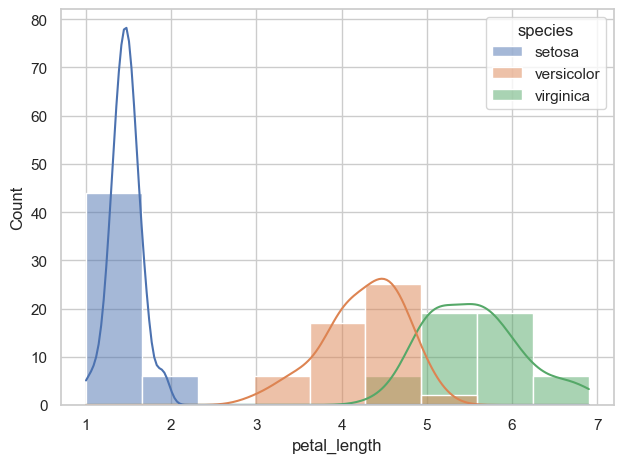

In [102]:
sns.histplot(data=df, x='petal_length', hue='species', kde=True)
plt.tight_layout()
plt.show()

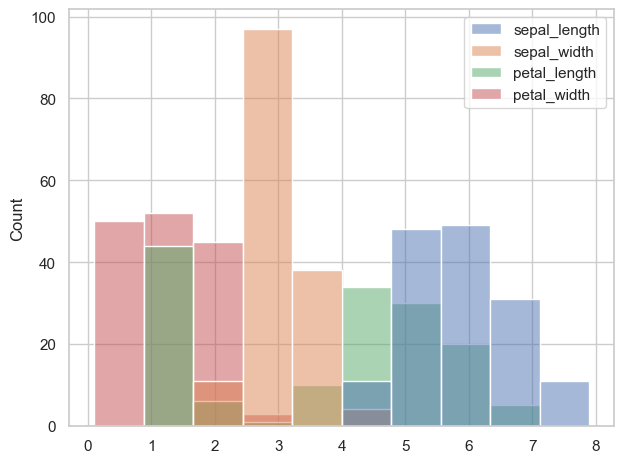

In [103]:
sns.histplot(df, bins=10)
plt.tight_layout()

##### Boxplot

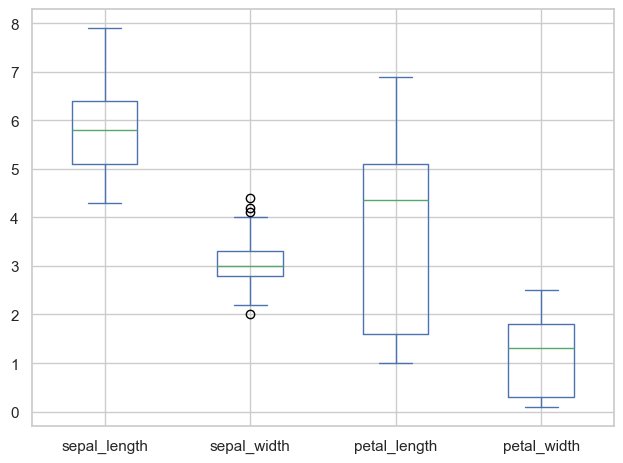

In [104]:
df.plot(kind='box')
plt.tight_layout()
plt.show()

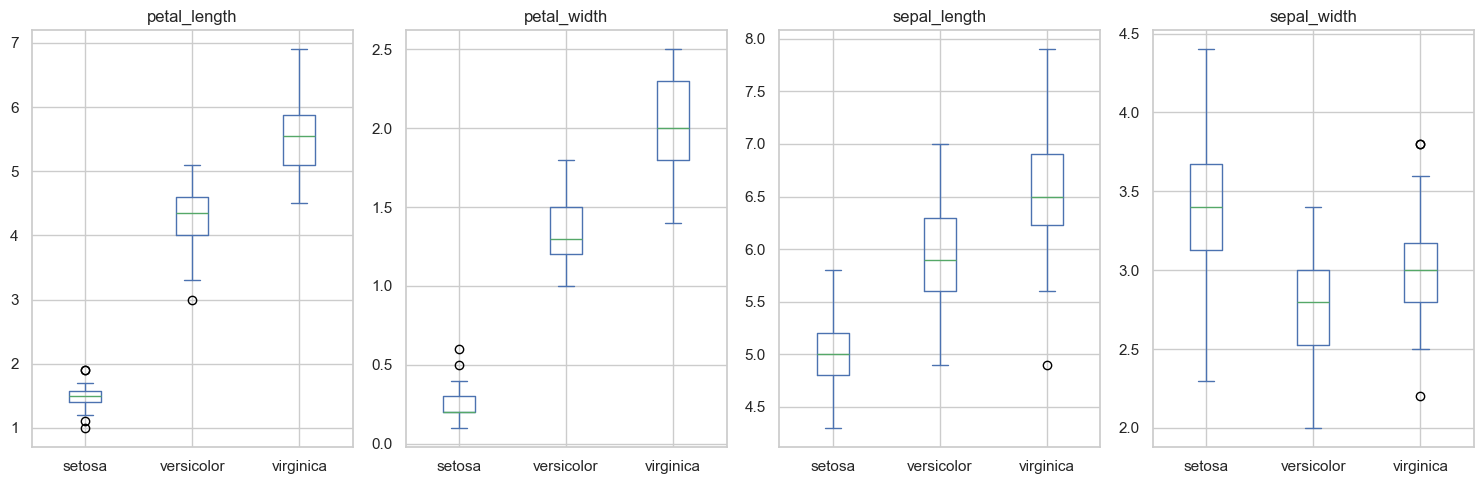

In [105]:
df.plot(kind='box', by='species', figsize=(15, 5))
plt.tight_layout()
plt.show()

<Axes: >

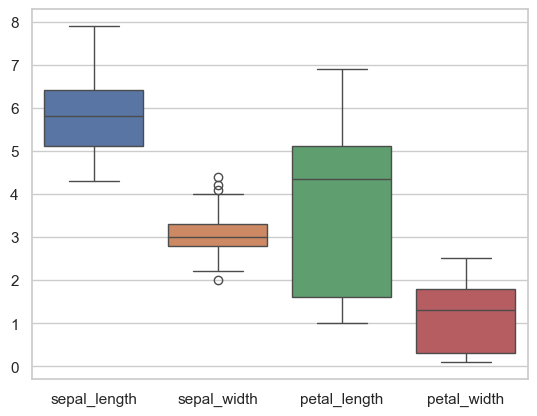

In [106]:
sns.boxplot(df)

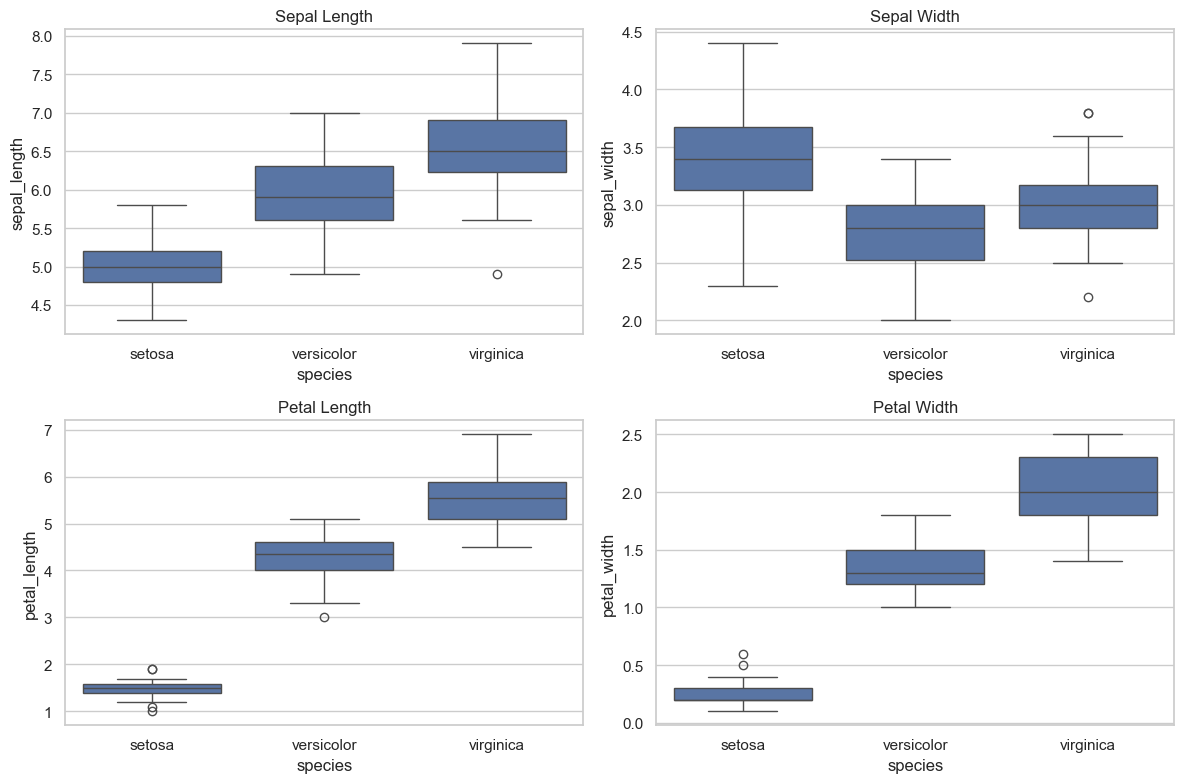

In [107]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='species', y='sepal_length', ax=ax[0][0])
ax[0][0].set_title('Sepal Length')

sns.boxplot(data=df, x='species', y='sepal_width', ax=ax[0][1])
ax[0][1].set_title('Sepal Width')

sns.boxplot(data=df, x='species', y='petal_length', ax=ax[1][0])
ax[1][0].set_title('Petal Length')

sns.boxplot(data=df, x='species', y='petal_width', ax=ax[1][1])
ax[1][1].set_title('Petal Width')

plt.tight_layout()
plt.show()

##### Violin Plot

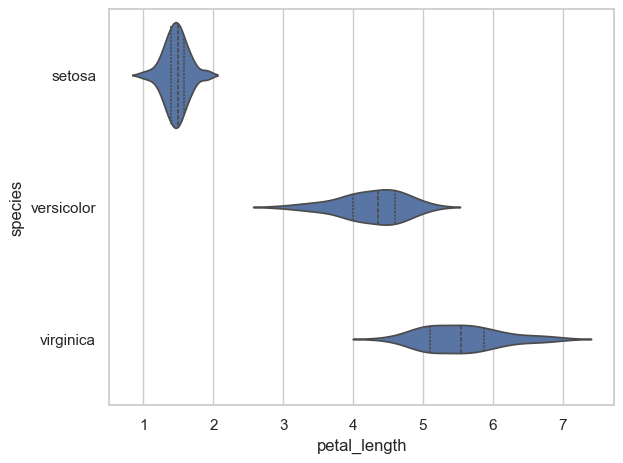

In [108]:
sns.violinplot(data=df, x='petal_length', y='species', inner='quartill')
plt.tight_layout()
plt.show()

##### Scatter Plot

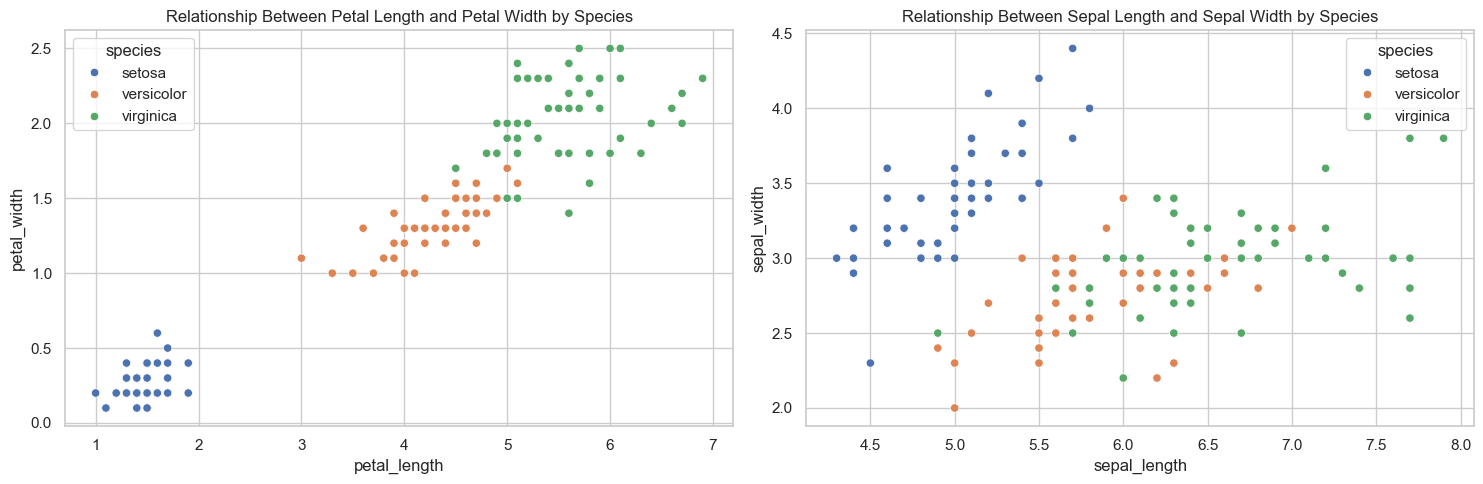

In [109]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', ax=ax[0])
ax[0].set_title('Relationship Between Petal Length and Petal Width by Species')

sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', ax=ax[1])
ax[1].set_title('Relationship Between Sepal Length and Sepal Width by Species')

plt.tight_layout()
plt.show()

Insight tentang hubungan (Relationship):
- Petal Length dan Petal Width menunjukkan hubungan linear yang kuat dan mampu memisahkan sebagian besar kelas dengan baik
- Species Setosa terlihat terpisah secara jelas, sedangkan Versicolor dan Virginica masih mengalami sedikit overlap
- Sebaliknya, Sepal Length dan Sepal Width tidak menunjukkan pemisahan yang jelas antar kelas karena banyak terjadi overlap
- Hal ini menunjukkan bahwa fitur petal lebih informatif dibandingkan fitur sepal dalam membedakan species
- Oleh karena itu, fitur petal_length dan petal_width menjadi kandidat utama dalam model klasifikasi

## Key Insights & Recommendations

### 1. Dataset Overview
- Dataset terdiri dari beberapa fitur numerik yaitu *sepal_length, sepal_width, petal_length, dan petal_width*
- Target variable adalah *species*, sehingga termasuk dalam **classification problem**

---

### 2. Key Findings from EDA
- Fitur *petal_length* dan *petal_width* memiliki hubungan linear yang kuat dan korelasi tinggi
- Kedua fitur tersebut mampu memisahkan sebagian besar kelas dengan baik
- Species *Setosa* terpisah secara jelas dari dua kelas lainnya (*Versicolor* dan *Virginica*)
- Fitur *sepal_length* dan *sepal_width* tidak menunjukkan pemisahan yang jelas antar kelas

---

### 3. Feature Importance Insight
- Fitur yang paling informatif: *petal_length* dan *petal_width*
- Fitur yang kurang informatif: *sepal_length* dan *sepal_width*
- Hal ini menunjukkan bahwa fitur *petal_length* dan *petal_width* lebih relevan untuk digunakan dalam model **klasifikasi**

---

### 4. Data Characteristics & Challenges
- Terdapat sedikit overlap antar kelas (*Versicolor* dan *Virginica*)
- Hubungan antar fitur petal bersifat linear
- Dataset relatif bersih (tidak ditemukan banyak missing value)

---

### 5. Model Recommendation
Berdasarkan hasil EDA, model yang direkomendasikan adalah:
- **K-Nearest Neighbors (KNN)** → karena data berbasis jarak dan memiliki pola cluster yang jelas
- Model lain seperti **Decision Tree** atau **SVM** juga dapat digunakan sebagai pembanding

---

### 6. Final Conclusion
- Dataset ini merupakan masalah klasifikasi dengan pola yang cukup jelas
- Fitur petal terbukti jauh lebih kuat dibandingkan fitur sepal dalam membedakan kelas
- Model berbasis jarak dan non-linear direkomendasikan untuk hasil optimal
- Dengan preprocessing yang tepat, model berpotensi menghasilkan performa yang tinggi

## 

# Iris Dataset: Data Pre-processing

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [111]:
print("="*80)
print("Data Pre-Processing")
print("="*80)

# ----------------------------------------------------------------------------
# 1. DATA CLEANING IMPLEMENTATION
# ----------------------------------------------------------------------------

print("\n[1] Checking missing value:")
print(df.isna().sum())

print("\n[1] Checking Duplicates:")
print("Duplicate rows:",df.duplicated().sum())


# ----------------------------------------------------------------------------
# 2. HANDLE MISSING VALUE, DUPLICATE & OUTLINER
# ----------------------------------------------------------------------------

print("\n[2] Handling Missing Value:")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    if df[col].isna().sum() > 0:
        skewness = df[col].skew()

        if abs(skewness) > 1:
            df[col].fillna(df[col].media(), inplace=True)

        else:
            df[col].fillna(df[col].media(), inplace=True)
            print(f"{col}: Filled with Mean (Normal Distribution)")
print(df.isna().sum())
print("Insight: Menggunakan startegi berbeda berdasarkan distribusi data")

print("\n[2] Handling Duplicates:")
df.drop_duplicates(inplace=True)
print("Duplicate rows:",df.duplicated().sum())

print("\n[2] Handling Outliers (IQR Method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    skewness = df[col].skew()

    if abs(skewness) > 1:
        multipler = 2.0 # lebih longgar untuk data skew
    else:
        multipler = 1.5 # tetap standar 1.5

    lower_round = Q1 - multipler * IQR
    upper_round = Q3 + multipler * IQR

    df[col] = np.where(df[col] < lower_round, lower_round, df[col]) 
    df[col] = np.where(df[col] > upper_round, upper_round, df[col])

    print(f"{col}: IQR capping dengan multipler {multipler}")
print("Insight: Outliner ditangani menggunakan metode capping (IQR) agar tidak menghilangkan data penting")
print("Insight: Threshold outliner disesuaikan dengan distribusi data")

print("\n[2] Handling Skewd Distribution:")

for col in numerical_cols:
    skewness = df[col].skew()

    if abs(skewness) > 1:
        df[col] = np.log1p(df[col])
        print(f"{col}: Applied log transformation (skewness =  {skewness:.2f})")
print("Insight: Log transform membantuk menormalkan distribusi data")

# ----------------------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ----------------------------------------------------------------------------

print("\n[3] Feature Engineering:")

df['petal_ratio'] = (df['petal_length'] / df['petal_width']).replace([np.inf, -np.inf], 0)
df['sepal_ratio'] = (df['sepal_length'] / df['sepal_width']).replace([np.inf, -np.inf], 0)
df['petal_area'] = (df['petal_length'] * df['petal_width'])
df['sepal_area'] = (df['sepal_length'] * df['sepal_width'])

print("Created features: petal_ratio, sepal_ratio, petal_area, sepal_area")
print("Insight: Feature ratio & area membantu meningkatkan pemisahan antar kelas")

# ----------------------------------------------------------------------------
# 4. ENCODING TARGET (KARNA KATEGORIKAL)
# ----------------------------------------------------------------------------

print("\n[4] Encoding Target...")
le = LabelEncoder()
df['species'] = pd.Series(
    le.fit_transform(df['species']), index=df.index
    )

print("Encoding Mapping:")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name} = {i}")
    

# ----------------------------------------------------------------------------
# 5. SPLIT FEATURE & TARGET
# ----------------------------------------------------------------------------

X = df.drop('species', axis=1)
y = df['species']

print("\nFeature shape:", X.shape)
print("Target Shape:", y.shape)

# ----------------------------------------------------------------------------
# 4. TRAIN TEST SPLIT
# ----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print("\nData Split:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

# ----------------------------------------------------------------------------
# 5. FEATURE SCALING
# ----------------------------------------------------------------------------

print("\nScaling Features")
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed")
print("Insight: Scaling penting untuk model berbasis jarak seperti KNN")

# ----------------------------------------------------------------------------
# 6. DONE
# ----------------------------------------------------------------------------

print("\n"+"="*80)
print("DATA PRE-PROCESSING COMPLETED")
print("="*80)

Data Pre-Processing

[1] Checking missing value:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

[1] Checking Duplicates:
Duplicate rows: 3

[2] Handling Missing Value:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Insight: Menggunakan startegi berbeda berdasarkan distribusi data

[2] Handling Duplicates:
Duplicate rows: 0

[2] Handling Outliers (IQR Method):
sepal_length: IQR capping dengan multipler 1.5
sepal_width: IQR capping dengan multipler 1.5
petal_length: IQR capping dengan multipler 1.5
petal_width: IQR capping dengan multipler 1.5
Insight: Outliner ditangani menggunakan metode capping (IQR) agar tidak menghilangkan data penting
Insight: Threshold outliner disesuaikan dengan distribusi data

[2] Handling Skewd Distribution:
Insight: Log transform membantuk menormalkan distribusi data

[3] Feature Engineering:
Created features: petal_ratio, sepal_ratio, petal_area, 